In [ ]:
# pip install imageio

   ---------------------------------------- 0.0/313.5 kB ? eta -:--:--
   --- ------------------------------------ 30.7/313.5 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------  307.2/313.5 kB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 313.5/313.5 kB 4.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import display, HTML
import glob
import os
import imageio
from tqdm import trange
from tqdm import tqdm
import numpy as np
import cv2
# image_load = np.ones([pixal_y_tbar+pixal_y_par*6,dim[1],4])*255
# cv2.imwrite(anim_dir+'backgrond.png', image_load)

# bring in a list of images and write to an output file

def make_movie_mp4(image_array, output_file):
    dpi = 200
    xpixels, ypixels = image_array[0].shape[0], image_array[0].shape[1]

    # make frames with each figure being the exact dimensions of our plots
    fig = plt.figure(figsize=(ypixels/dpi, xpixels/dpi), dpi=dpi)
    im = plt.figimage(image_array[0])

    def animate(i):
        im.set_array(image_array[i])
        return (im)

    mywriter = animation.FFMpegWriter(fps=24, bitrate=-1)
    anim = animation.FuncAnimation(fig, animate, frames=len(image_array), interval=60)
    anim.save(output_file,mywriter)

    return anim

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


LG00_linear_x_time120
Num of PNG file: 101


<ipython-input-3-f725510e7262>:37: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  original_image = imageio.imread(png_read_ti)


(600, 2400, 4)


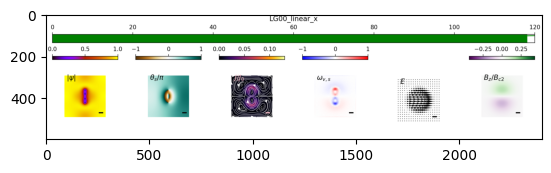

tbar
psi
phase
J
w_nu
E
Bz
(375, 400, 4)
(80, 400, 4)


<ipython-input-3-f725510e7262>:85: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  original_image = imageio.imread(png_read_ti)


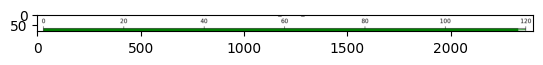

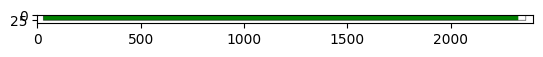

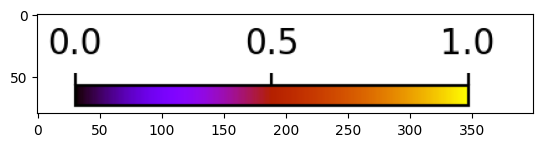

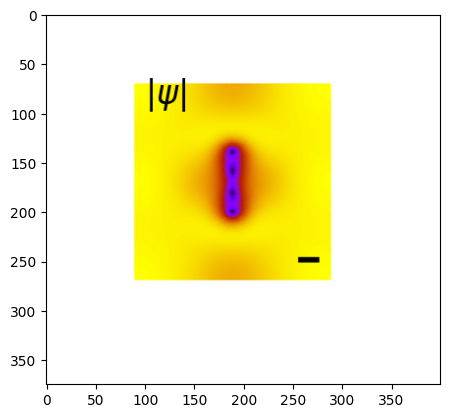

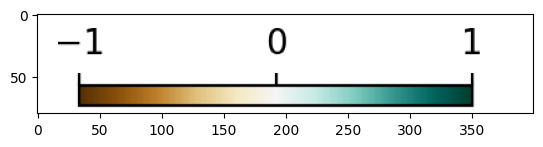

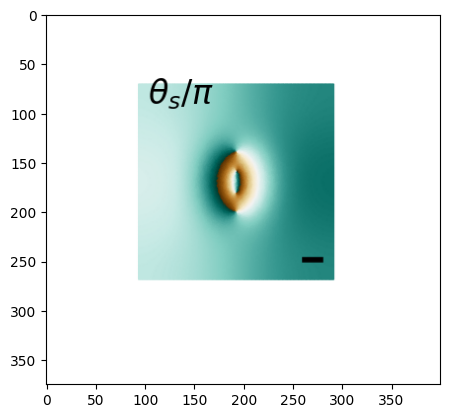

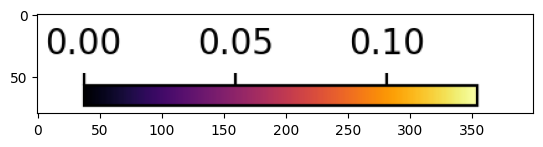

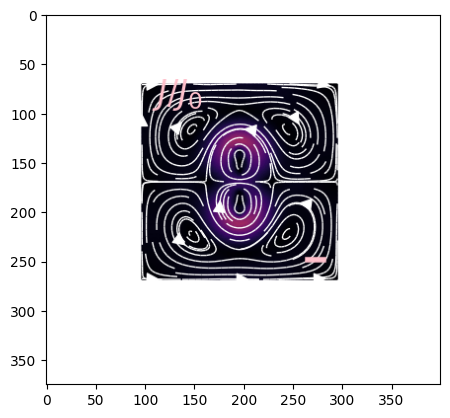

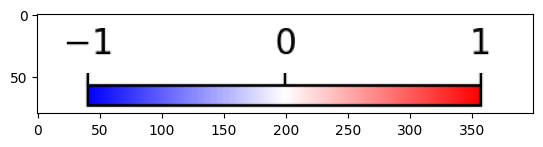

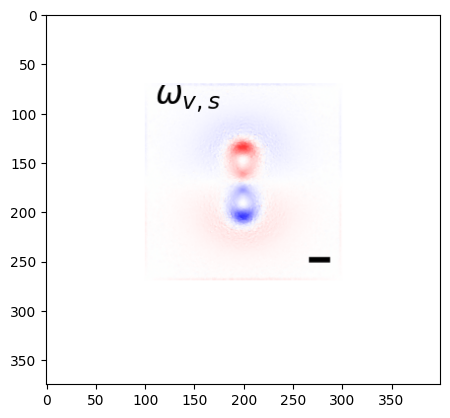

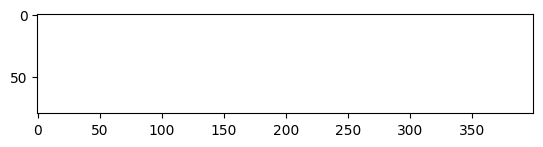

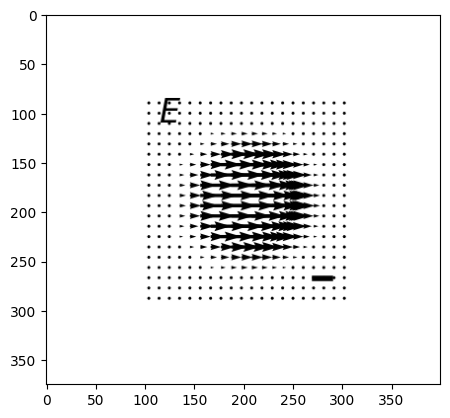

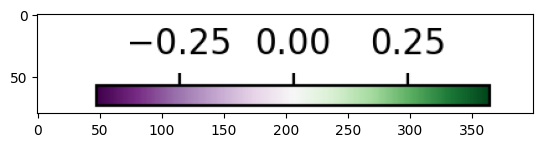

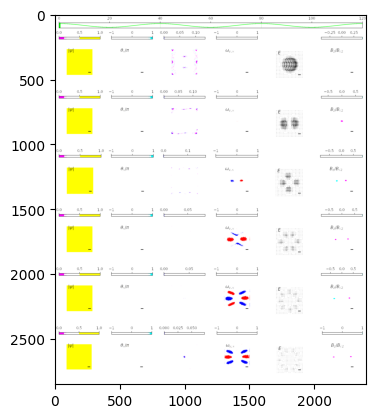

In [3]:
from inspect import EndOfBlock

# define directories

p, l, s = 0, 0, 0
L = 2


folder_name = r'/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/'
anim_dir = folder_name
output_file = 's'+str(s)+'_p'+str(p) # the .mp4 extention will be added below

# foldernames_read = glob.glob(os.path.join(folder_name + 'LG*'))

def folder_LGmode(p,l,s):
  if s==-1: sText = '_circular_r'
  if s==0: sText = '_linear_x'
  if s==1: sText = '_circular_l'
  return 'LG'+str(p)+str(l)+sText+'_time120'

### Print out the number of PNG for all folder
# for s in [-1,0,1]:
#   for l in range(6):
#     for p in range(3):
#       sub_foldername = folder_name + folder_LGmode(p,l,s)
#       png_read = glob.glob(os.path.join(sub_foldername + '/*.png'))
#       print(folder_LGmode(p,l,s))
#       print('Num of PNG file: '+str(len(png_read)))

### Get dimention of single figure of #folder_LGmode(p,l,s)
p, l, s = p, l, s
sub_foldername = folder_name + folder_LGmode(p,l,s)
png_read = glob.glob(os.path.join(sub_foldername + '/*.png'))
png_read_ti = png_read[3]
print(folder_LGmode(p,l,s))
print('Num of PNG file: '+str(len(png_read_ti)))
original_image = imageio.imread(png_read_ti)
dim = original_image.shape
print(original_image.shape) # (600, 2400, 4)
plt.figure()
plt.imshow(original_image[:,:,:])
plt.show()
width_subplot = int(dim[1]/6)
type_set = ['tbar','psi','phase','J','w_nu','E','Bz']
range_set = {'tbar':  {0:0,1:dim[1],2:30,3:150,4:0,5:dim[2]},
             'psi':   {0:width_subplot*0,1:width_subplot*1,2:145,3:dim[0],4:0,5:dim[2]},
             'phase': {0:width_subplot*1,1:width_subplot*2,2:145,3:dim[0],4:0,5:dim[2]},
             'J':     {0:width_subplot*2,1:width_subplot*3,2:145,3:dim[0],4:0,5:dim[2]},
             'w_nu':  {0:width_subplot*3,1:width_subplot*4,2:145,3:dim[0],4:0,5:dim[2]},
             'E':     {0:width_subplot*4,1:width_subplot*5,2:145,3:dim[0],4:0,5:dim[2]},
             'Bz':    {0:width_subplot*5,1:width_subplot*6,2:145,3:dim[0],4:0,5:dim[2]},
             'par':   {0:width_subplot*0,1:width_subplot*6,2:145,3:dim[0],4:0,5:dim[2]},}
pixel_y_tbar = range_set['tbar'][3]-range_set['tbar'][2]
pixel_x_tbar = range_set['tbar'][1]-range_set['tbar'][0]
pixel_y_par = range_set['par'][3]-range_set['par'][2]

### Test of splited plots
for typenum in range(7):
  plottype = type_set[typenum]
  print(plottype)
  image_load = np.copy(original_image)
  sub_image = image_load[range_set[plottype][2]:range_set[plottype][3],range_set[plottype][0]:range_set[plottype][1],:]
  sub_image_cbar = sub_image[:80,:,:]
  sub_image_data = sub_image[80:,:,:]
  # plt.imshow(image_load[range_set[plottype][0]:range_set[plottype][1],range_set[plottype][2]:range_set[plottype][3],:])
  plt.figure()
  plt.imshow(sub_image_cbar)
  plt.figure()
  plt.imshow(sub_image_data)
dim2 = sub_image_data.shape
pixel_x_data = int(dim2[1])
pixel_y_data = int(dim2[0])
print(dim2) # (375, 400, 4)
dim3 = sub_image_cbar.shape
pixel_x_cbar = int(dim3[1])
pixel_y_cbar = int(dim3[0])
print(dim3) # (80, 400, 4)

### Check configuration
ti_frame = range(0,1201,5)
for ti in [5]:
  for l in range(6):
    sub_foldername = folder_name + folder_LGmode(p,l,s)
    png_read_ti = os.path.join(sub_foldername + '/'+str(ti)+'.png')
    original_image = imageio.imread(png_read_ti)
    if l==0:
        plottype = 'tbar'
        image_load = np.zeros([pixel_y_tbar+pixel_y_par*6,dim[1],4])
        image_load[0:pixel_y_tbar,:,:] = original_image[range_set[plottype][2]:range_set[plottype][3],range_set[plottype][0]:range_set[plottype][1],:]
    plottype = 'par'
    image_load[pixel_y_tbar+pixel_y_par*l:pixel_y_tbar+pixel_y_par*(l+1),:,:] = original_image[range_set[plottype][2]:range_set[plottype][3],range_set[plottype][0]:range_set[plottype][1],:]
  plt.imshow(image_load)


In [4]:
def PNG2fig(subtitle,*, plottype_set=['psi'], ti_frame=[0], QNs=['000'], offset=15, varType='QN'):

  ### Load parameters
  if varType.lower()=='qn': var_set = QNs
  if varType.lower()=='ti': var_set = ti_frame
  y1, y2, y3 = pixel_y_tbar, pixel_y_tbar+pixel_y_cbar, pixel_y_tbar+pixel_y_cbar+pixel_y_data*len(var_set)

  try:
      var_set
  except NameError:
      print("var_set WASN'T defined after all.")
  else:
    # image_load = imageio.imread(anim_dir+'backgrond.png')
    image_load = np.ones([pixel_y_tbar+pixel_y_cbar+pixel_y_data*len(plottype_set),pixel_x_tbar,4])*255
    print(image_load.shape)
    count2 = 0
    for var in var_set:
      print('Load var of '+varType+' = '+str(var))
      if varType.lower()=='qn': s, l, p, ti= int(var[0]), int(var[1]), int(var[2]), ti_frame[0]
      else: s, l, p, ti = int(QNs[0][0]), int(QNs[0][1]), int(QNs[0][2]), int(var)
      if s==3: s=-1
      count1 = 0
      for plottype in plottype_set:
        sub_foldername = folder_name + folder_LGmode(p,l,s)
        png_read_ti = os.path.join(sub_foldername + '/'+str(ti)+'.png')
        if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)
        else: print('Empty file: ti '+str(ti)+', p '+str(p))
        ### Write image
        sub_image = original_image[range_set[plottype][2]:range_set[plottype][3],range_set[plottype][0]:range_set[plottype][1],:]
        sub_image_cbar = sub_image[:80,offset:-offset,:]
        sub_image_data = sub_image[80+offset:-offset,offset:-offset,:]
        x1 = sub_image_data.shape[1]
        y6 = sub_image_data.shape[0]
        y4, y5 = y6*(count2), y6*(count2+1)
        image_load[y4:y5,(count1)*x1:(count1+1)*x1,:] = sub_image_data
        count1 += 1
      count2 += 1

    cv2.imwrite(anim_dir+'temp4/'+subtitle+'.png', image_load)
    plt.imshow(image_load)

  ''' Done. '''

def PNG2fig_t(subtitle,*, plottype_set=['psi'], ti_frame=[0], QNs=['000'], offset=15, varType='QN'):

  ### Load parameters
  if varType.lower()=='qn': var_set = QNs
  if varType.lower()=='ti': var_set = ti_frame
  y1, y2, y3 = pixel_y_tbar, pixel_y_tbar+pixel_y_cbar, pixel_y_tbar+pixel_y_cbar+pixel_y_data*len(var_set)

  try:
      var_set
  except NameError:
      print("var_set WASN'T defined after all.")
  else:
    # image_load = imageio.imread(anim_dir+'backgrond.png')
    image_load = np.ones([pixel_y_tbar+pixel_y_cbar+pixel_y_data*len(plottype_set),pixel_x_tbar,4])*255
    print(image_load.shape)
    count2 = 0
    for var in var_set:
      print('Load var of '+varType+' = '+str(var))
      if varType.lower()=='qn': s, l, p, ti= int(var[0]), int(var[1]), int(var[2]), ti_frame[0]
      else: s, l, p, ti = int(QNs[0][0]), int(QNs[0][1]), int(QNs[0][2]), int(var)
      if s==3: s=-1
      count1 = 0
      for plottype in plottype_set:
        sub_foldername = folder_name + folder_LGmode(p,l,s)
        png_read_ti = os.path.join(sub_foldername + '/'+str(ti)+'.png')
        if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)
        else: print('Empty file: ti '+str(ti)+', p '+str(p))
        ### Write image
        sub_image = original_image[range_set[plottype][2]:range_set[plottype][3],range_set[plottype][0]:range_set[plottype][1],:]
        sub_image_cbar = sub_image[:80,offset:-offset,:]
        sub_image_data = sub_image[80+offset:-offset,offset:-offset,:]
        x1 = sub_image_data.shape[1]
        y6 = sub_image_data.shape[0]
        y4, y5 = y6*(count1), y6*(count1+1)
        image_load[y4:y5,(count2)*x1:(count2+1)*x1,:] = sub_image_data
        count1 += 1
      count2 += 1

    cv2.imwrite(anim_dir+'temp4/'+subtitle+'.png', image_load)
    plt.imshow(image_load)

def findQN(raw,nraw,col,ncol,fix,nfix):
  match raw:
    case 's': s=nraw
    case 'l': l=nraw
    case 'p': p=nraw
  match col:
    case 's': s=ncol
    case 'l': l=ncol
    case 'p': p=ncol
  match fix:
    case 's': s=nfix
    case 'l': l=nfix
    case 'p': p=nfix
  return s, l, p

def PNG2fig_QN(subtitle,*, plottype_set=['psi'], ti_frame=[0], offset=15, raw='l', col='s',fix='p',fixnum=0):

  ### Load parameters
  QNrange_set = {'s':[-1,0,1], 'l':[0,1,2,3,4,5], 'p':[0,1,2]}
  raw_set = QNrange_set[raw]
  col_set = QNrange_set[col]
  plottype = plottype_set[0]
  y1, y2, y3 = 0, 0+pixel_y_cbar, 0+pixel_y_cbar+pixel_y_data*len(col_set)

  try:
      raw_set
  except NameError:
      print("raw_set WASN'T defined after all.")
  else:
    # image_load = imageio.imread(anim_dir+'backgrond.png')
    image_load = np.ones([pixel_y_tbar+pixel_y_cbar+pixel_y_data*len(col_set),pixel_x_data*len(raw_set),4])*255
    print(image_load.shape)
    count2 = 0
    for nraw in raw_set:
      print('Load var of '+raw+' = '+str(nraw))
      ti = ti_frame[0]
      count1 = 0
      for ncol in col_set:
        s, l, p = findQN(raw,nraw,col,ncol,fix,fixnum)
        sub_foldername = folder_name + folder_LGmode(p,l,s)
        png_read_ti = os.path.join(sub_foldername + '/'+str(ti)+'.png')
        if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)
        else: print('Empty file: ti '+str(ti)+', p '+str(p))
        ### Write image
        sub_image = original_image[range_set[plottype][2]:range_set[plottype][3],range_set[plottype][0]:range_set[plottype][1],:]
        sub_image_cbar = sub_image[:80,offset:-offset,:]
        sub_image_data = sub_image[80+offset:-offset,offset:-offset,:]
        x1 = sub_image_data.shape[1]
        y6 = sub_image_data.shape[0]
        y4, y5 = y6*(count1), y6*(count1+1)
        image_load[y4:y5,(count2)*x1:(count2+1)*x1,:] = sub_image_data
        count1 += 1
      count2 += 1

    cv2.imwrite(anim_dir+'temp4/'+subtitle+'.png', image_load)
    plt.imshow(image_load)

  ''' Done. '''

def PNG2fig_test(subtitle,*, plottype_set=['psi'], ti_frame=[0], QNs=['000'], offset=15, var_set=['_test1','_test2']):

  ### Load parameters
  y1, y2, y3 = pixel_y_tbar, pixel_y_tbar+pixel_y_cbar, pixel_y_tbar+pixel_y_cbar+pixel_y_data*len(var_set)

  try:
      var_set
  except NameError:
      print("var_set WASN'T defined after all.")
  else:
    # image_load = imageio.imread(anim_dir+'backgrond.png')
    image_load = np.ones([pixel_y_tbar+pixel_y_cbar+pixel_y_data*len(plottype_set),pixel_x_tbar,4])*255
    print(image_load.shape)
    count2 = 0
    for var in var_set:
      print('Load var: '+str(var))
      s, l, p, ti = int(QNs[0][0]), int(QNs[0][1]), int(QNs[0][2]), ti_frame[0]
      if s==3: s=-1
      count1 = 0
      for plottype in plottype_set:
        sub_foldername = folder_name + folder_LGmode(p,l,s)
        png_read_ti = os.path.join(sub_foldername+var+'/'+str(ti)+'.png')
        if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)
        else: print('Empty file: ti '+str(ti)+', p '+str(p))
        ### Write image
        sub_image = original_image[range_set[plottype][2]:range_set[plottype][3],range_set[plottype][0]:range_set[plottype][1],:]
        sub_image_cbar = sub_image[:80,offset:-offset,:]
        sub_image_data = sub_image[80+offset:-offset,offset:-offset,:]
        x1 = sub_image_data.shape[1]
        y6 = sub_image_data.shape[0]
        y4, y5 = y6*(count1), y6*(count1+1)
        image_load[y4:y5,(count2)*x1:(count2+1)*x1,:] = sub_image_data
        count1 += 1
      count2 += 1

    cv2.imwrite(anim_dir+'temp4/'+subtitle+'.png', image_load)
    plt.imshow(image_load)

  ''' Done. '''



# Fig 3

(2075, 2400, 4)
Load var of ti = 100


<ipython-input-44-27f55b6effcb>:25: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of ti = 900


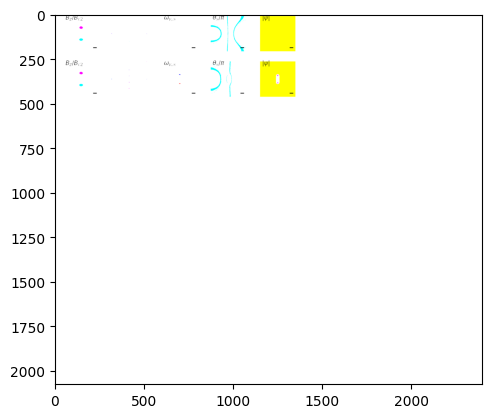

In [ ]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

set1 = ['Bz', 'J','w_nu','phase','psi']
set2 = [100,900]
set3 = ['000'] # 'slp'
PNG2fig('fig3', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='ti')

# Fig 5

(575, 2400, 4)
Load var of ti = 745
Load var of ti = 780


<ipython-input-4-f738109d7414>:69: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of ti = 890
Load var of ti = 935
(575, 2400, 4)
Load var of ti = 745


Load var of ti = 780
Load var of ti = 890
Load var of ti = 935


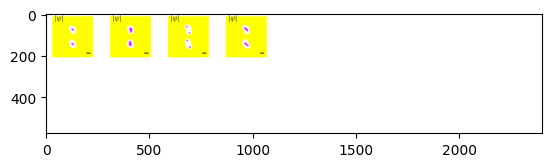

In [10]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

# set2 = [745, 770, 890, 935]
set2 = [745, 780, 890, 935]
set3 = ['010'] # 'slp'

set1 = ['phase']
PNG2fig_t('fig5_phase', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='ti')

set1 = ['psi']
PNG2fig_t('fig5_psi', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='ti')

# Fig 6

(575, 2400, 4)
Load var of ti = 720
Load var of ti = 780
Load var of ti = 800
Load var of ti = 860
Load var of ti = 920


<ipython-input-49-173ccde50a46>:68: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


(575, 2400, 4)
Load var of ti = 720
Load var of ti = 780
Load var of ti = 800
Load var of ti = 860
Load var of ti = 920


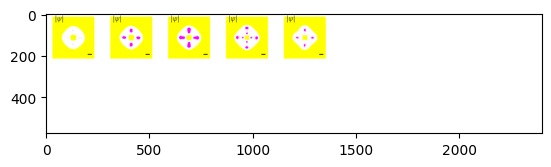

In [ ]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

set2 = [720, 780, 800, 860, 920]
set3 = ['110'] # 'slp'

set1 = ['phase']
PNG2fig_t('fig6_phase', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='ti')

set1 = ['psi']
PNG2fig_t('fig6_psi', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='ti')

# Fig 7

(2075, 2400, 4)
Load var of QN = 110
Load var of QN = 310


<ipython-input-53-c3a79fb2115b>:26: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


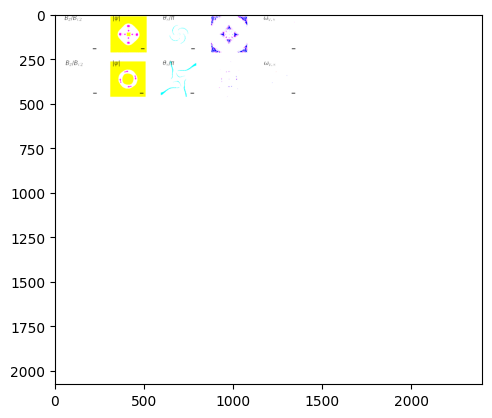

In [ ]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

set1 = ['Bz','psi','phase','J','w_nu']
set2 = [860]
set3 = ['110','310'] # 'slp'
PNG2fig('fig7', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='QN')

# Fig 8

(2075, 2400, 4)
Load var of QN = 010
Load var of QN = 020


<ipython-input-53-c3a79fb2115b>:70: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of QN = 030
Load var of QN = 040
Load var of QN = 050


(1325, 2400, 4)
Load var of QN = 010
Load var of QN = 020
Load var of QN = 030
Load var of QN = 040
Load var of QN = 050


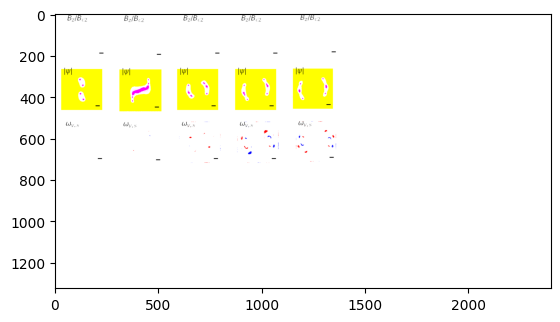

In [ ]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

set1 = ['Bz','psi','phase','J','w_nu']
set2 = [900]
set3 = ['010','020','030','040','050'] # 'slp'
PNG2fig_t('fig8v1', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='QN')

set1 = ['Bz','psi','w_nu']
set2 = [900]
set3 = ['010','020','030','040','050'] # 'slp'
PNG2fig_t('fig8v2', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='QN')

# Fig 9

(2075, 2400, 4)
Load var of QN = 110


<ipython-input-53-c3a79fb2115b>:70: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of QN = 120
Load var of QN = 130
Load var of QN = 140
Load var of QN = 150


(1325, 2400, 4)
Load var of QN = 110
Load var of QN = 120
Load var of QN = 130
Load var of QN = 140
Load var of QN = 150


(2075, 2400, 4)
Load var of QN = 310
Load var of QN = 320
Load var of QN = 330
Load var of QN = 340
Load var of QN = 350


(1325, 2400, 4)
Load var of QN = 310
Load var of QN = 320
Load var of QN = 330
Load var of QN = 340
Load var of QN = 350


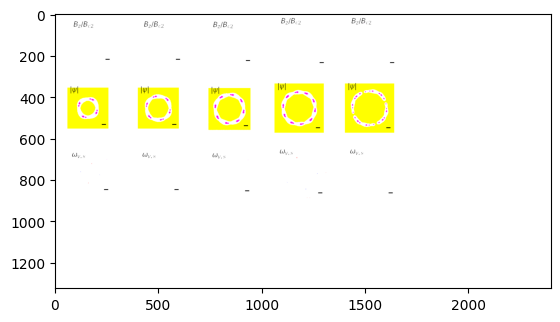

In [ ]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

set2 = [1195]

set3 = ['110','120','130','140','150'] # 'slp'
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_t('fig9s1v1', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='QN')
set1 = ['Bz','psi','w_nu']
PNG2fig_t('fig9s1v2', plottype_set=set1, ti_frame=set2, QNs=set3, offset=60, varType='QN')

set3 = ['310','320','330','340','350'] # 'slp'
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_t('fig9s3v1', plottype_set=set1, ti_frame=set2, QNs=set3, offset=30, varType='QN')
set1 = ['Bz','psi','w_nu']
PNG2fig_t('fig9s3v2', plottype_set=set1, ti_frame=set2, QNs=set3, offset=30, varType='QN')

# Fig 10a

# Fig 10b

(2075, 2400, 4)
Load var: _test1


<ipython-input-66-cb4f57633546>:166: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var: 


(1325, 2400, 4)
Load var: _test1
Load var: 


(2075, 2400, 4)
Load var: 
Load var: _test1


(1325, 2400, 4)
Load var: 
Load var: _test1


(2075, 2400, 4)
Load var: _test1
Load var: 


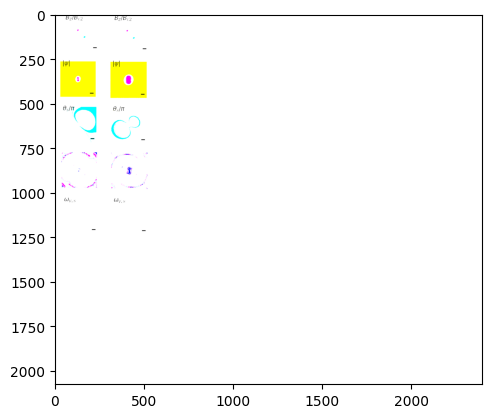

In [71]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

ti_set = [950]

QNs = ['120'] # 'slp'
var_set=['_test1','']
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_test('fig10b_QN'+QNs[0]+'_v1', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, var_set=var_set)
set1 = ['Bz','psi','phase']
PNG2fig_test('fig10b_QN'+QNs[0]+'_v2', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, var_set=var_set)

QNs = ['100'] # 'slp'
var_set=['','_test1']
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_test('fig10b_QN'+QNs[0]+'_v1', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, var_set=var_set)
set1 = ['Bz','psi','phase']
PNG2fig_test('fig10b_QN'+QNs[0]+'_v2', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, var_set=var_set)


ti_set = [950]

QNs = ['120'] # 'slp'
var_set=['_test1','']
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_test('fig10b_QN'+QNs[0]+'_v3', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, var_set=var_set)


# Fig 10c

(2075, 2400, 4)
Load var of QN = 130


<ipython-input-44-06f23f57c5cd>:26: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of QN = 310
Load var of QN = 140
Load var of QN = 320


(1325, 2400, 4)
Load var of QN = 130
Load var of QN = 310
Load var of QN = 140
Load var of QN = 320


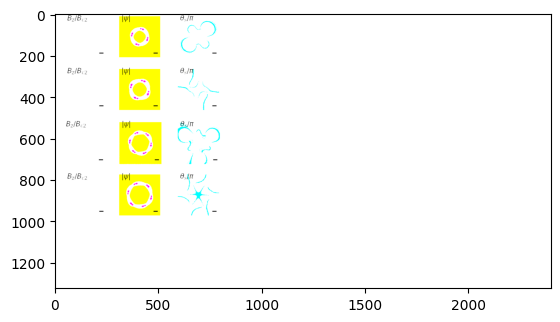

In [62]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

ti_set = [1000]

QNs = ['130','310','140','320'] # 'slp'

set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig('fig10cv1', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, varType='QN')
set1 = ['Bz','psi','phase']
PNG2fig('fig10cv2', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, varType='QN')

# Fig 11a

(2075, 2400, 4)
Load var of ti = 450


<ipython-input-44-06f23f57c5cd>:69: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of ti = 475
Load var of ti = 500


(950, 2400, 4)
Load var of ti = 450
Load var of ti = 475
Load var of ti = 500


(2075, 2400, 4)
Load var of ti = 470
Load var of ti = 520
Load var of ti = 560


(950, 2400, 4)
Load var of ti = 470
Load var of ti = 520
Load var of ti = 560


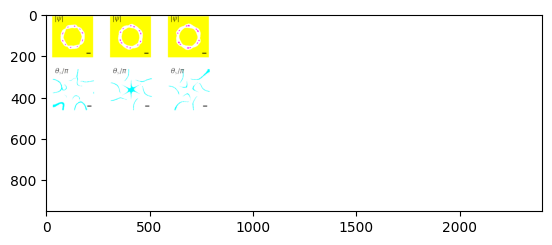

In [59]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

QNs = ['140'] # 'slp'
ti_set = [450, 475, 500]
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_t('fig11a_QN'+QNs[0]+'_v1', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, varType='ti')
set1 = ['psi','phase']
PNG2fig_t('fig11a_QN'+QNs[0]+'_v2', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, varType='ti')

QNs = ['320'] # 'slp'
ti_set = [470, 520, 560]
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_t('fig11a_QN'+QNs[0]+'_v1', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, varType='ti')
set1 = ['psi','phase']
PNG2fig_t('fig11a_QN'+QNs[0]+'_v2', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, varType='ti')


# Fig 11b

(2075, 2400, 4)
Load var: 


<ipython-input-44-06f23f57c5cd>:166: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var: _test1
Load var: _test2


(1325, 2400, 4)
Load var: 
Load var: _test1
Load var: _test2


(2075, 2400, 4)
Load var: 
Load var: _test1
Load var: _test2


(1325, 2400, 4)
Load var: 
Load var: _test1
Load var: _test2


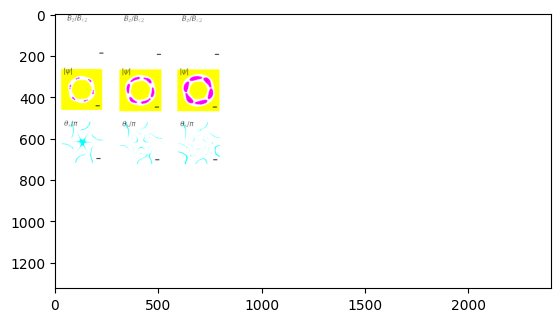

In [48]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

ti_set = [1000]

QNs = ['140'] # 'slp'
var_set=['','_test1','_test2']
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_test('fig11b_QN'+QNs[0]+'_v1', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, var_set=var_set)
set1 = ['Bz','psi','phase']
PNG2fig_test('fig11b_QN'+QNs[0]+'_v2', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, var_set=var_set)

QNs = ['320'] # 'slp'
var_set=['','_test1','_test2']
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_test('fig11b_QN'+QNs[0]+'_v1', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, var_set=var_set)
set1 = ['Bz','psi','phase']
PNG2fig_test('fig11b_QN'+QNs[0]+'_v2', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=60, var_set=var_set)


# Fig 12

(2075, 2400, 4)
Load var of ti = 0
Load var of ti = 100


<ipython-input-66-cb4f57633546>:69: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of ti = 200
Load var of ti = 300
Load var of ti = 400
Load var of ti = 500


(950, 2400, 4)
Load var of ti = 0
Load var of ti = 100
Load var of ti = 200
Load var of ti = 300
Load var of ti = 400
Load var of ti = 500


(2075, 2400, 4)
Load var of ti = 0
Load var of ti = 100
Load var of ti = 200
Load var of ti = 300
Load var of ti = 400
Load var of ti = 500


(950, 2400, 4)
Load var of ti = 0
Load var of ti = 100
Load var of ti = 200
Load var of ti = 300
Load var of ti = 400
Load var of ti = 500


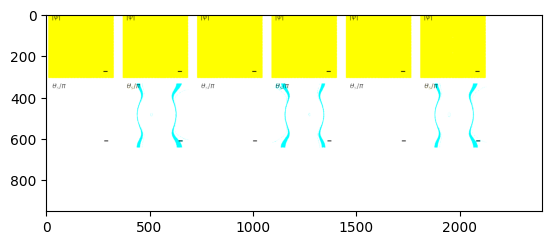

In [76]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

QNs = ['001'] # 'slp'
ti_set = [0, 100, 200, 300, 400, 500]
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_t('fig12_QN'+QNs[0]+'_v1', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=40, varType='ti')
set1 = ['psi','phase']
PNG2fig_t('fig12_QN'+QNs[0]+'_v2', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=40, varType='ti')


QNs = ['002'] # 'slp'
ti_set = [0, 100, 200, 300, 400, 500]
set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig_t('fig12_QN'+QNs[0]+'_v1', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=20, varType='ti')
set1 = ['psi','phase']
PNG2fig_t('fig12_QN'+QNs[0]+'_v2', plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=20, varType='ti')


# Fig 13

(2075, 2400, 4)
Load var of QN = 152


<ipython-input-53-c3a79fb2115b>:26: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of QN = 122


(1325, 2400, 4)
Load var of QN = 152
Load var of QN = 122


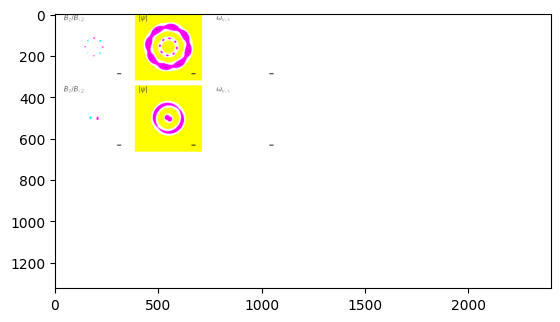

In [ ]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'

# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

offset = 15
varType = 'QN'

set2 = [1195]
set3 = ['152','122'] # 'slp'

set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig('fig13s1v1', plottype_set=set1, ti_frame=set2, QNs=set3, offset=offset, varType=varType)
set1 = ['Bz','psi','w_nu']
PNG2fig('fig13s1v2', plottype_set=set1, ti_frame=set2, QNs=set3, offset=offset, varType=varType)


# Fig 14

(2075, 2400, 4)
Load var of QN = 112
Load var of QN = 312


<ipython-input-11-c3a79fb2115b>:26: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of QN = 341


(1325, 2400, 4)
Load var of QN = 112
Load var of QN = 312
Load var of QN = 341


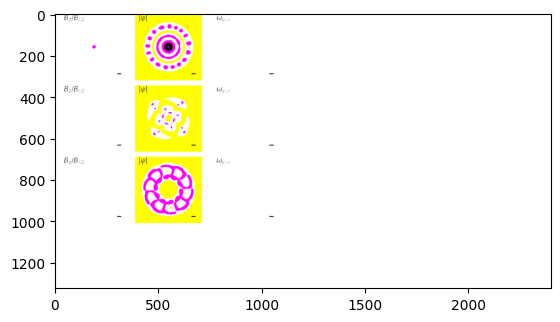

In [12]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'

# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

offset = 15
varType = 'QN'

set2 = [1195]
set3 = ['112','312','341'] # 'slp'

set1 = ['Bz','psi','phase','J','w_nu']
PNG2fig('fig14s1v1', plottype_set=set1, ti_frame=set2, QNs=set3, offset=offset, varType=varType)
set1 = ['Bz','psi','w_nu']
PNG2fig('fig14s1v2', plottype_set=set1, ti_frame=set2, QNs=set3, offset=offset, varType=varType)


# Fig 15

(2450, 1200, 4)
Load var of p = 0


<ipython-input-32-79bb8a53c765>:127: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


...

(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


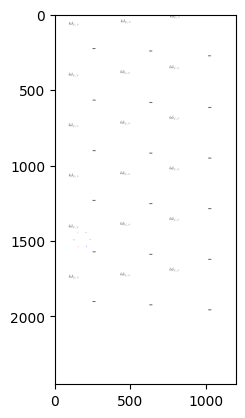

In [38]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'

# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

offset = 20
ti_frame = [1000]

set1 = ['psi']
raw, col, fix, fixnum = ['p', 'l', 's', -1]
PNG2fig_QN('fig15_'+set1[0]+'_s'+str(fixnum), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 0]
PNG2fig_QN('fig15_'+set1[0]+'_s'+str(fixnum), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 1]
PNG2fig_QN('fig15_'+set1[0]+'_s'+str(fixnum), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)

set1 = ['phase']
raw, col, fix, fixnum = ['p', 'l', 's', -1]
PNG2fig_QN('fig15_'+set1[0]+'_s'+str(fixnum), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 0]
PNG2fig_QN('fig15_'+set1[0]+'_s'+str(fixnum), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 1]
PNG2fig_QN('fig15_'+set1[0]+'_s'+str(fixnum), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)

set1 = ['w_nu']
raw, col, fix, fixnum = ['p', 'l', 's', -1]
PNG2fig_QN('fig15_'+set1[0]+'_s'+str(fixnum), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 0]
PNG2fig_QN('fig15_'+set1[0]+'_s'+str(fixnum), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 1]
PNG2fig_QN('fig15_'+set1[0]+'_s'+str(fixnum), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)


# Appendix: Bz and $\omega_{nu,s}$

(2450, 1200, 4)
Load var of p = 0


<ipython-input-32-79bb8a53c765>:127: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


(2450, 1200, 4)
Load var of p = 0
Load var of p = 1
Load var of p = 2


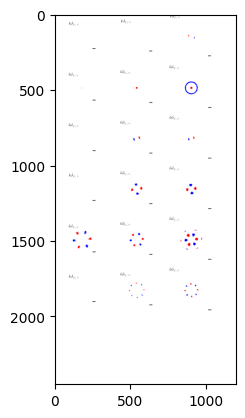

In [39]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'

# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']

offset = 20
ti_frame = [20]

set1 = ['Bz']
raw, col, fix, fixnum = ['p', 'l', 's', -1]
PNG2fig_QN('figA1_'+set1[0]+'_s'+str(fixnum)+'_t'+str(ti_frame[0]), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 0]
PNG2fig_QN('figA1_'+set1[0]+'_s'+str(fixnum)+'_t'+str(ti_frame[0]), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 1]
PNG2fig_QN('figA1_'+set1[0]+'_s'+str(fixnum)+'_t'+str(ti_frame[0]), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)

set1 = ['w_nu']
raw, col, fix, fixnum = ['p', 'l', 's', -1]
PNG2fig_QN('figA1_'+set1[0]+'_s'+str(fixnum)+'_t'+str(ti_frame[0]), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 0]
PNG2fig_QN('figA1_'+set1[0]+'_s'+str(fixnum)+'_t'+str(ti_frame[0]), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)
raw, col, fix, fixnum = ['p', 'l', 's', 1]
PNG2fig_QN('figA1_'+set1[0]+'_s'+str(fixnum)+'_t'+str(ti_frame[0]), plottype_set=set1, ti_frame=ti_frame, offset=offset, raw=raw, col=col, fix=fix, fixnum=fixnum)



# Regular Snapshot (Fig 4, 5, 6, 10a)

(2075, 2400, 4)
Load var of ti = 850


<ipython-input-4-f738109d7414>:69: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


Load var of ti = 900
Load var of ti = 950
Load var of ti = 1000
Load var of ti = 1050


(2075, 2400, 4)
Load var of ti = 700
Load var of ti = 750
Load var of ti = 800
Load var of ti = 850
Load var of ti = 900


(2075, 2400, 4)
Load var of ti = 750
Load var of ti = 800
Load var of ti = 850
Load var of ti = 900
Load var of ti = 950


(2075, 2400, 4)
Load var of ti = 750
Load var of ti = 800
Load var of ti = 850
Load var of ti = 900
Load var of ti = 950


(2075, 2400, 4)
Load var of ti = 750
Load var of ti = 800
Load var of ti = 850
Load var of ti = 900
Load var of ti = 950


(2075, 2400, 4)
Load var of ti = 750
Load var of ti = 800
Load var of ti = 850
Load var of ti = 900
Load var of ti = 950


(2075, 2400, 4)
Load var of ti = 750
Load var of ti = 800
Load var of ti = 850
Load var of ti = 900
Load var of ti = 950


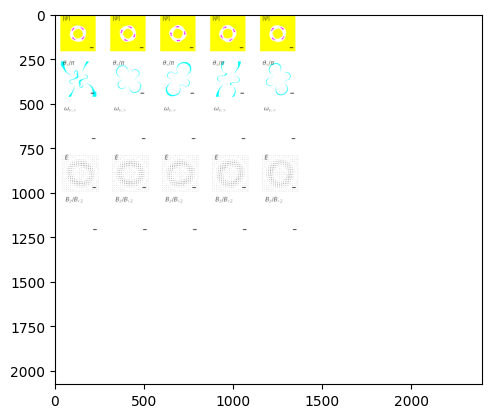

In [6]:
# offset = 15 # L=4
# offset = 60 # L=2.5
# varType = 'ti' or 'QN'
# type_set = ['tbar','psi','phase','J','w_nu','E','Bz']
set1 = ['psi','phase','w_nu','E','Bz']
offset = 60

### Fig 4

QNs = ['000'] # 'slp'
ti_set = np.array([0, 50, 100, 150, 200])+850
PNG2fig_t('Snapshot_fig4_QN'+QNs[0], plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=offset, varType='ti')

QNs = ['100'] # 'slp'
ti_set = np.array([0, 50, 100, 150, 200])+700
PNG2fig_t('Snapshot_fig4_QN'+QNs[0], plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=offset, varType='ti')

### Fig 5

QNs = ['010'] # 'slp'
ti_set = np.array([0, 50, 100, 150, 200])+750
PNG2fig_t('Snapshot_fig5_QN'+QNs[0], plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=offset, varType='ti')

### Fig 6

QNs = ['110'] # 'slp'
ti_set = np.array([0, 50, 100, 150, 200])+750
PNG2fig_t('Snapshot_fig6_QN'+QNs[0], plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=offset, varType='ti')

QNs = ['310'] # 'slp'
ti_set = np.array([0, 50, 100, 150, 200])+750
PNG2fig_t('Snapshot_fig6b_QN'+QNs[0], plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=offset, varType='ti')


### Fig 10a

QNs = ['120'] # 'slp'
ti_set = np.array([0, 50, 100, 150, 200])+750
PNG2fig_t('Snapshot_fig10a_QN'+QNs[0], plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=offset, varType='ti')

QNs = ['130'] # 'slp'
ti_set = np.array([0, 50, 100, 150, 200])+750
PNG2fig_t('Snapshot_fig10a_QN'+QNs[0], plottype_set=set1, ti_frame=ti_set, QNs=QNs, offset=offset, varType='ti')


# Reform color

In [91]:
from pathlib import Path

folder_name_color = r'/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/color_transfer'
folder_name_color_output = r'/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/color_transfer_output'

png_read = glob.glob(os.path.join(folder_name + '/*.png'))
print('Write PNG file to ...')
for png_read_i in png_read:
  image_load = imageio.imread(png_read_i)
  print(folder_name_color_output+'/'+Path(png_read_i).stem+'.png')
  cv2.imwrite(folder_name_color_output+'/'+Path(png_read_i).stem+'.png', image_load)
''' Done. '''


Write PNG file to ...


<ipython-input-91-42282092a698>:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image_load = imageio.imread(png_read_i)


/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/color_transfer_output/2.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/color_transfer_output/LG01_circular_l_time120_SC_abstract_psi_flat.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/color_transfer_output/LG00_linear_x_time120_SC_abstract_psi_tilt.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/color_transfer_output/LG00_linear_x_time120_SC_abstract_psi_flat.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/color_transfer_output/LG00_circular_l_time120_SC_abstract_psi_tilt.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/color_transfer_output/LG00_circular_l_time120_SC_abstract_psi_flat_wrong.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/color_transfer_output/LG01_linear_x_time120_SC_abstract_psi_tilt.png
/content/drive/MyDrive/Colab Notebooks/TempData/2

' Done. '

# Reform color for color bar

In [95]:

folder_name_color = r'/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all'
folder_name_color_output = r'/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/colorbar_transfer_output'
ti = 10

png_read = glob.glob(os.path.join(folder_name + '/*.png'))
print('Write PNG file to ...')
for png_read_i in png_read:
  for s in [-1,0,1]:
    for l in [0,1,2,3,4,5]:
      for p in [0,1,2]:
        sub_foldername = folder_name_color + '/' + folder_LGmode(p,l,s)
        png_read_i = os.path.join(sub_foldername + '/' + str(ti)+'.png')
        image_load = imageio.imread(png_read_i)
        print(folder_name_color_output+'/'+folder_LGmode(p,l,s)+'.png')
        cv2.imwrite(folder_name_color_output+'/'+folder_LGmode(p,l,s)+'.png', image_load)
''' Done. '''

Write PNG file to ...


<ipython-input-95-f421c442dfe8>:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image_load = imageio.imread(png_read_i)


/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/colorbar_transfer_output/LG00_circular_r_time120.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/colorbar_transfer_output/LG10_circular_r_time120.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/colorbar_transfer_output/LG20_circular_r_time120.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/colorbar_transfer_output/LG01_circular_r_time120.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/colorbar_transfer_output/LG11_circular_r_time120.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/colorbar_transfer_output/LG21_circular_r_time120.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/colorbar_transfer_output/LG02_circular_r_time120.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/colorbar_transfer_output/LG12_circular_r_time120.png
/content

' Done. '

In [94]:
folder_LGmode(p,l,s)

'LG00_circular_r_time120'

  0%|          | 0/1 [00:00<?, ?it/s]<ipython-input-5-4a44b772e85a>:14: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)
100%|██████████| 1/1 [00:05<00:00,  5.87s/it]


' Done. '

<ipython-input-5-0d8dc9da002d>:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image_load = imageio.imread(anim_dir+'backgrond.png')
<ipython-input-5-0d8dc9da002d>:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(png_read_ti) > 10: original_image = imageio.imread(png_read_ti)


/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/LG20_linear_x_time120/0.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/LG21_linear_x_time120/0.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/LG22_linear_x_time120/0.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/LG23_linear_x_time120/0.png
/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/LG24_linear_x_time120/0.png


ValueError: could not broadcast input array from shape (455,2400,4) into shape (420,2400,4)

In [ ]:
# plt.imshow(image_load)
# imageio.imread(image_load)
image_load.shape

(2815, 2400, 4)

In [ ]:
# images = []

# for i in trange(len(filenames)):

#     # this checks to make sure there's more than 0 bytes in the filename
#     if patch_num==0:
#       if os.path.getsize(filenames[i]) > 10: images.append(imageio.imread(filenames[i]))
#     if patch_num>0:
#       if os.path.getsize(filenames[i]) > 10:
#         patched_image = imageio.imread(filenames[i])
#         for i in range(patch_num):
#           patched_image[patch_range[str(i)]['x1']:patch_range[str(i)]['x2'],patch_range[str(i)]['y1']:patch_range[str(i)]['y2'],:] = patch_image[patch_range[str(i)]['x1']:patch_range[str(i)]['x2'],patch_range[str(i)]['y1']:patch_range[str(i)]['y2'],:]
#           images.append(patched_image)

# # use our function to make the movie
# anim = make_movie_mp4(images, anim_dir + output_file + '.mp4')

# ''' Done. '''

2400

In [ ]:
just to follow up on Heather QC' answer, here is an illustration of the np.stack functions and which dimensions are concerned:

arr1 = np.array([[[1,2],[2,3]],
                 [[1,2],[2,3]],
                 [[1,2],[2,3]]])

arr2 = np.array([[[5,6],[8,7]],
                 [[7,6],[7,8]],
                 [[6,7],[7,8]]])

print("arr1 shape  ", arr1.shape)
print("arr2 shape  ", arr2.shape)
print("vstack shape", np.vstack((arr1, arr2)).shape)
print("hstack shape", np.hstack((arr1, arr2)).shape)
print("dstack shape", np.dstack((arr1, arr2)).shape)

>>> arr1 shape   (3, 2, 2)
>>> arr2 shape   (3, 2, 2)
>>> vstack shape (6, 2, 2)
>>> hstack shape (3, 4, 2)
>>> dstack shape (3, 2, 4)

In [ ]:
range_set[plottype][1]
range_set[plottype][0]
dim[0]
# range(width_subplot*1,width_subplot*2)
# original_image[range_set[plottype][1]][range_set[plottype][0]][:].shape
# plt.imshow(original_image[range(200,400)][np.array(range_set[plottype][1]),:])
# range_set[plottype][1]
# range_set[plottype][1]
np.array(ti_frame)

array([   0,    5,   10,   15,   20,   25,   30,   35,   40,   45,   50,
         55,   60,   65,   70,   75,   80,   85,   90,   95,  100,  105,
        110,  115,  120,  125,  130,  135,  140,  145,  150,  155,  160,
        165,  170,  175,  180,  185,  190,  195,  200,  205,  210,  215,
        220,  225,  230,  235,  240,  245,  250,  255,  260,  265,  270,
        275,  280,  285,  290,  295,  300,  305,  310,  315,  320,  325,
        330,  335,  340,  345,  350,  355,  360,  365,  370,  375,  380,
        385,  390,  395,  400,  405,  410,  415,  420,  425,  430,  435,
        440,  445,  450,  455,  460,  465,  470,  475,  480,  485,  490,
        495,  500,  505,  510,  515,  520,  525,  530,  535,  540,  545,
        550,  555,  560,  565,  570,  575,  580,  585,  590,  595,  600,
        605,  610,  615,  620,  625,  630,  635,  640,  645,  650,  655,
        660,  665,  670,  675,  680,  685,  690,  695,  700,  705,  710,
        715,  720,  725,  730,  735,  740,  745,  7

In [ ]:

# define directories

folder_name = r'/content/drive/MyDrive/Colab Notebooks/TempData/20240823_MakeVideo_all/'
foldernames_read = glob.glob(os.path.join(image_dir + '*.png'))

image_dir = folder_name+image_folder+'/'
anim_dir = folder_name
output_file = image_folder # the .mp4 extention will be added below

# bring in a list of images and write to an output file

def make_movie_mp4(image_array, output_file):
    dpi = 200
    xpixels, ypixels = image_array[0].shape[0], image_array[0].shape[1]

    # make frames with each figure being the exact dimensions of our plots
    fig = plt.figure(figsize=(ypixels/dpi, xpixels/dpi), dpi=dpi)
    im = plt.figimage(image_array[0])

    def animate(i):
        im.set_array(image_array[i])
        return (im)

    mywriter = animation.FFMpegWriter(fps=24, bitrate=-1)
    anim = animation.FuncAnimation(fig, animate, frames=len(image_array), interval=60)
    anim.save(output_file,mywriter)

    return anim

# Go through each filename and add it to our image stack
# filenames = sorted(glob.glob(os.path.join(image_dir + '*.png')))
filenames_read = glob.glob(os.path.join(image_dir + '*.png'))
print(len(filenames_read))
# filenames_read


filenames = np.copy(filenames_read)
for i in range(len(filenames)):
  filenames[i] = image_dir + str(int(i*5))+'.png'
filenames


241


array(['/content/drive/MyDrive/Colab Notebooks/TempData/20240816_MakeAnimation/LG12_circular_r_time120/0.png',
       '/content/drive/MyDrive/Colab Notebooks/TempData/20240816_MakeAnimation/LG12_circular_r_time120/5.png',
       '/content/drive/MyDrive/Colab Notebooks/TempData/20240816_MakeAnimation/LG12_circular_r_time120/10.png',
       '/content/drive/MyDrive/Colab Notebooks/TempData/20240816_MakeAnimation/LG12_circular_r_time120/15.png',
       '/content/drive/MyDrive/Colab Notebooks/TempData/20240816_MakeAnimation/LG12_circular_r_time120/20.png',
       '/content/drive/MyDrive/Colab Notebooks/TempData/20240816_MakeAnimation/LG12_circular_r_time120/25.png',
       '/content/drive/MyDrive/Colab Notebooks/TempData/20240816_MakeAnimation/LG12_circular_r_time120/30.png',
       '/content/drive/MyDrive/Colab Notebooks/TempData/20240816_MakeAnimation/LG12_circular_r_time120/35.png',
       '/content/drive/MyDrive/Colab Notebooks/TempData/20240816_MakeAnimation/LG12_circular_r_time120/40.

# Make patch

' Done. '

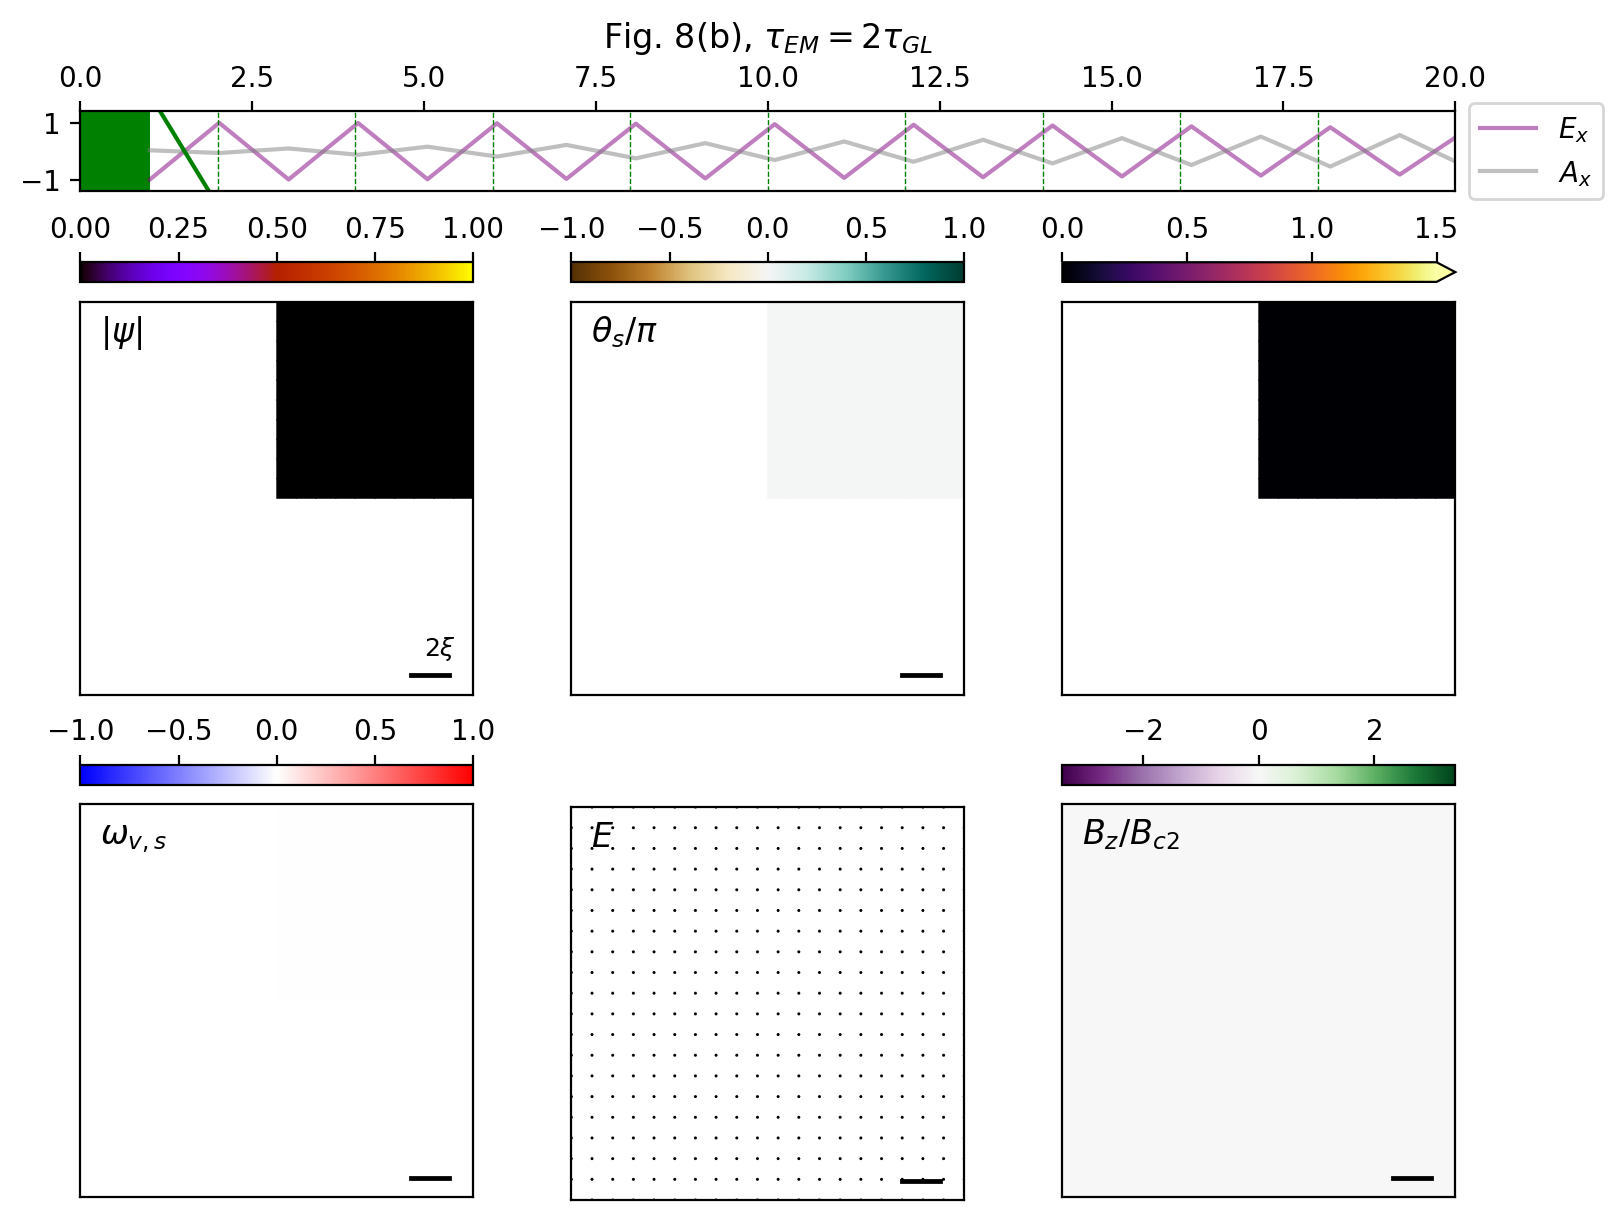

In [ ]:
### Make revised part of png

### Build-up subplot

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
import matplotlib.transforms as mtrans

dpi=200
fps=20
# w_input = 2*np.pi/40
# E0i = 2
solve_time = 20
save_frame = 3
# max_frame = int(len(time)/save_frame)
# frame_set = np.arange(max_frame)*save_frame
# frame_set = frame_set[343:]
frame_set = [1]

iniframe = frame_set[0]

ti_set = [1,2,3]
Parameter_set = ti_set
K0 = 2.095153729869544
time = np.linspace(0,100,100) # Virtual time !!!!!!!!!!!!!!!!!!!!
Bc2_value = 3 # virtual value !!!!!!!!!!!!!!!!!!!!
w_input = 2*np.pi/2
xi = 0.1
MAKE_ANIMATIONS = True
quiver_mesh_n = 20
    # xlim = [(Xtri/xi).min(), (Xtri/xi).max()]
    # ylim = [(Ytri/xi).min(), (Ytri/xi).max()]
xlim = [-10, 10]
ylim = [-10, 10]

mag_cmap = "gnuplot"#"viridis"
phase_cmap = "BrBG"#"twilight_shifted"
vorticity_cmap = "bwr"
j_cmap = 'inferno'
cmap_all = [' ',mag_cmap, phase_cmap, j_cmap, vorticity_cmap, ' ', "PRGn"]
vmin_all = [  0,       0,        -1,       0,             -1,   0,    -3.4]
vmax_all = [  1,       1,         1,     1.5,              1,   1,     3.4]
# rset = np.linspace(0, 1, 100)
# vorticity_cmap = ListedColormap((new_cbar(rset))**1.5)#"bwr"

psi_label = "$|\\psi|$"
phase_label = "$\\theta_s / \\pi$"
vorticity_label = "$\\omega_{v,s}$"
j_label = "$J/J_0$"
label_all = [' ', psi_label, phase_label, j_label, vorticity_label,'$E$','$B_z/B_{c2}$']
labelfontsize = 12
labelcolor_all = [' ', 'k', 'k', 'white', 'k', 'k', 'k']

# create objects
fig = plt.figure(constrained_layout=True, figsize=(8,6), dpi=dpi)
gs = GridSpec(3, 3, figure=fig, height_ratios = [0.6, 3, 3], width_ratios = [1, 1, 1])

# create sub plots as grid
ax = {}
ax[0] = fig.add_subplot(gs[0, 0:])
ax[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

ax1 = ax[0]
color = 'purple'
# ax1.set_xlabel('Time ($\\tau_{GL}$)')
# ax1.set_ylabel('$E_{x}$', color=color)
ax1.plot(time[iniframe:], 1*np.cos(time[iniframe:]*w_input), color=color, alpha=0.5, label='$E_x$')
color = 'gray'
# ax1.set_ylabel('$A_{x}$', color=color)  # we already handled the x-label with ax1
ax1.plot(time[iniframe:], -1*np.sin(time[iniframe:]*w_input), color=color, alpha=0.5, label='$A_x$')
# ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([-1.4,1.4])
ax1.set_xlim([0,solve_time])
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.set_yticks([-1,1])
ax1.set_title('Fig. 8(b), $\\tau_{EM}=2\\tau_{GL}$')
left, bottom, width, height = (0, -2, time[iniframe], 4)
rect = plt.Rectangle((left, bottom), width, height,
                     facecolor="green", alpha=1)
ax1.add_patch(rect)
for Nti in range(int(solve_time*w_input/2/np.pi)+1): ax1.axvline(x=(Nti)*(2*np.pi/w_input),color='g',linestyle='dashed',linewidth=0.5)

ax[1] = fig.add_subplot(gs[1, 0])
ax[2] = fig.add_subplot(gs[1, 1])
ax[3] = fig.add_subplot(gs[1, 2])
ax[4] = fig.add_subplot(gs[-1, 0])
ax[5] = fig.add_subplot(gs[-1, 1])
ax[6] = fig.add_subplot(gs[-1, 2])


if MAKE_ANIMATIONS:

# Basic sattings
    height = 2
    width = 2
    w0 = 0.4
    X = np.linspace(-width/2,width/2,quiver_mesh_n)
    Y = np.linspace(-height/2,height/2,quiver_mesh_n)
    Xv, Yv = np.meshgrid(X, Y)
    virtual_2D_data = np.zeros_like(Xv)
    virtual_2D_data_x = np.zeros_like(Xv)
    virtual_2D_data_y = np.zeros_like(Xv)
    shading = "gouraud"
    # fps = 10
    # dpi= 100
    max_cols = 6
    min_frame = 0
    max_frame = -1
    autoscale = False
    dimensionles = False
    axis_labels = False
    axes_off = False
    title_off = False
    full_title = True
    logger = None
    figure_kwargs = None
    writer = None
    quiver_scale = 1
    # quiver_mesh_n = 20
    width_quiver = 0.08
    dimensionless = False
    # quantities = ("order_parameter", "phase")
    # output_file = folder_name+'/'+'test'+"_video.mp4"

    def timescan(frame):
        yout = np.ones_like(time)*(-2)
        yout[frame] = 2
        return yout

    for num_set in frame_set:
            collections = []

            # num_set = 1 # Change here for test !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
            ti = time
            Nti = num_set

            axn = ax[0]
            collection = axn.plot(time, timescan(num_set), color='green')
            # collections.append(collection)

            # E_x, E_y = E_input_frame(Xv,Yv,ti,take_real=False)
            # B_x, B_y, B_z = E2Bv(Xv,Yv,E0i*E_x,E0i*E_y,constant_Bz,c,w_input)

            for i in range(1,5):

                Z_value = virtual_2D_data
                cmap = str(np.copy(cmap_all[i]))
                label = str(np.copy(label_all[i]))
                vmax = np.copy(vmax_all[i])
                vmin = np.copy(vmin_all[i])
                labeltextcolor = str(np.copy(labelcolor_all[i]))

                axn = ax[i]
                collection = axn.pcolormesh(Z_value,
                        shading=shading,
                        cmap=cmap,
                        vmin=vmin,
                        vmax=vmax,
                    )
                # if i==3: axn.streamplot(Xv/xi, Yv/xi, Jx, Jy, color="white", density=.8, linewidth=0.5)
                if num_set==iniframe:
                  if i!=3: cbar = fig.colorbar(collection, ax=axn, location='top')
                if num_set==iniframe:
                  if i==3: cbar = fig.colorbar(collection, ax=axn, location='top',extend='max')
                # cbar.set_label(opts.clabel)
                axn.set_aspect("equal")
                axn.set_xlim(xlim)
                axn.set_ylim(ylim)
                axn.set_xticks([])
                axn.set_yticks([])
                if num_set==iniframe:
                  if int(i)==1: axn.text(7.5,-8,'$2\\xi$', fontsize=9)
                fontprops = fm.FontProperties(size=4, family='monospace')
                scalebar = AnchoredSizeBar(axn.transData,
                               2, '            ', 'lower right',
                               pad=0.15,
                               color=labeltextcolor,
                               frameon=False,
                               size_vertical=.1,fontproperties=fontprops)
                axn.add_artist(scalebar)
                axn.text(-9,8,label, fontsize=labelfontsize, color=labeltextcolor)
                # collections.append(collection)

            if True: # For new plot: "E"
                i = 5
                label = str(np.copy(label_all[i]))
                axn = ax[i]
                if num_set>iniframe: collection_E = axn.clear()
                collection_E = axn.quiver(
                                    X/xi,
                                    Y/xi,
                                    virtual_2D_data_x,
                                    virtual_2D_data_y,
                                    scale=quiver_scale,
                                    scale_units='x',
                                    width=width_quiver*abs(X[2]-X[1]),)
                axn.set_aspect("equal")
                axn.set_xlim(xlim)
                axn.set_ylim(ylim)
                axn.set_xticks([])
                axn.set_yticks([])
                fontprops = fm.FontProperties(size=4, family='monospace')
                scalebar = AnchoredSizeBar(axn.transData,
                               2, '            ', 'lower right',
                               pad=0.15,
                               color=labeltextcolor,
                               frameon=False,
                               size_vertical=.1,fontproperties=fontprops)
                axn.add_artist(scalebar)
                axn.text(-9,8,label, fontsize=labelfontsize, color=labeltextcolor)
                # if num_set==0: collections.append(collection_E)

            if True: # For new plot: "Bz"
                i = 6
                vmax = np.copy(vmax_all[i])
                vmin = np.copy(vmin_all[i])
                label = str(np.copy(label_all[i]))
                axn = ax[i]
                collection = axn.pcolormesh(
                        Xv/xi,
                        Yv/xi,
                        virtual_2D_data,
                        cmap="PRGn",
                        shading='gouraud',
                        vmin=vmin,
                        vmax=vmax,
                )
                if num_set==iniframe: cbar = plt.colorbar(collection, ax=axn, location='top')
                # cbar.set_label('$B_{z}$ ['+field_units+']')
                axn.set_aspect("equal")
                # axn.set_title('$B_{z}$ ')
                axn.set_xlim(xlim)
                axn.set_ylim(ylim)
                axn.set_xticks([])
                axn.set_yticks([])
                fontprops = fm.FontProperties(size=4, family='monospace')
                scalebar = AnchoredSizeBar(axn.transData,
                               2, '            ', 'lower right',
                               pad=0.15,
                               color=labeltextcolor,
                               frameon=False,
                               size_vertical=.1,fontproperties=fontprops)
                axn.add_artist(scalebar)

                axn.text(-9,8,label, fontsize=labelfontsize, color=labeltextcolor)
                # collections.append(collection)
            plt.savefig(folder_name+'frame_for_patch.png')


file_patch = folder_name+'frame_for_patch.png'
''' Done. '''

In [ ]:
from IPython.display import display, Image

i = 0

patch_num = 0
patch_range = {}
patch_range['0'] = {'x1':700,'x2':780,'y1':1000,'y2':1460,}
patch_range['1'] = {'y1':0,'y2':-1,'x1':0,'x2':50,}

if patch_num>0:
    # this checks to make sure there's more than 0 bytes in the filename
    if os.path.getsize(filenames[i]) > 10:
      original_image = imageio.imread(filenames[i])
      print(original_image.shape)
      plt.imshow(original_image[:,:,:])
      plt.show()
      patch_image = imageio.imread(file_patch)
      print(patch_image.shape)
      plt.imshow(patch_image[:,:,:])
      plt.show()
      patched_image = original_image
      for i in range(patch_num):
        plt.imshow(original_image[patch_range[str(i)]['x1']:patch_range[str(i)]['x2'],patch_range[str(i)]['y1']:patch_range[str(i)]['y2'],:])
        plt.show()
        plt.imshow(patch_image[patch_range[str(i)]['x1']:patch_range[str(i)]['x2'],patch_range[str(i)]['y1']:patch_range[str(i)]['y2'],:])
        plt.show()
        patched_image[patch_range[str(i)]['x1']:patch_range[str(i)]['x2'],patch_range[str(i)]['y1']:patch_range[str(i)]['y2'],:] = patch_image[patch_range[str(i)]['x1']:patch_range[str(i)]['x2'],patch_range[str(i)]['y1']:patch_range[str(i)]['y2'],:]
      plt.imshow(patched_image[:,:,:])
      plt.show()

# np.shape(filenames[i])

# Make .mp4 with patch

In [ ]:
images = []

for i in trange(len(filenames)):

    # this checks to make sure there's more than 0 bytes in the filename
    if patch_num==0:
      if os.path.getsize(filenames[i]) > 10: images.append(imageio.imread(filenames[i]))
    if patch_num>0:
      if os.path.getsize(filenames[i]) > 10:
        patched_image = imageio.imread(filenames[i])
        for i in range(patch_num):
          patched_image[patch_range[str(i)]['x1']:patch_range[str(i)]['x2'],patch_range[str(i)]['y1']:patch_range[str(i)]['y2'],:] = patch_image[patch_range[str(i)]['x1']:patch_range[str(i)]['x2'],patch_range[str(i)]['y1']:patch_range[str(i)]['y2'],:]
          images.append(patched_image)

# use our function to make the movie
anim = make_movie_mp4(images, anim_dir + output_file + '.mp4')

''' Done. '''

  0%|          | 0/241 [00:00<?, ?it/s]<ipython-input-23-91c56d34d290>:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  if os.path.getsize(filenames[i]) > 10: images.append(imageio.imread(filenames[i]))
100%|██████████| 241/241 [01:30<00:00,  2.68it/s]


' Done. '

<Figure size 2400x600 with 0 Axes>

In [ ]:
print(anim_dir)
print(output_file + '.mp4')

/content/drive/MyDrive/Colab Notebooks/TempData_collect20240705_MakeVideo/20240625_makeAnimation/
/content/drive/MyDrive/Colab Notebooks/TempData_collect20240705_MakeVideo/20240625_makeAnimation//test_video.mp4.mp4
